In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/merged_311_nypd_weekly.csv'
df = pd.read_csv(file_path)
display(df.head())

,precinct,week,complaint_count,crime_count
0,1,2,641,163
1,1,3,622,164
2,1,4,725,147
3,1,5,660,137
4,1,6,604,177


### 1. Data Loading, Preprocessing, and CNN Model Definition

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Data (Predict if next week's crime_count is greater than 140)
# Sort by precinct and week, then shift to get next week's crime_count
df_sorted = df.sort_values(by=['precinct', 'week']).copy()
df_sorted['next_week_crime_count'] = df_sorted.groupby('precinct')['crime_count'].shift(-1)
# Remove rows where next week's data is missing
df_clean = df_sorted.dropna(subset=['next_week_crime_count']).copy()

# Extract raw features
X_raw = df_clean[['precinct', 'week', 'complaint_count']]
# Convert target to binary classification: 0 for <= 140, 1 for > 140
y = (df_clean['next_week_crime_count'].values > 140).astype(np.float32)

# Split into training and test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# Data preprocessing: One-hot encode 'precinct', standardize numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['precinct']),
        ('num', StandardScaler(), ['week', 'complaint_count'])
    ])

X_train_scaled = preprocessor.fit_transform(X_train_raw)
X_test_scaled = preprocessor.transform(X_test_raw)

num_features = X_train_scaled.shape[1]
print(f"Total number of features after one-hot encoding: {num_features}")

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 2. Define a simple 1D CNN model
class SimpleCNN(nn.Module):
    def __init__(self, num_features):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        # Kernel size is 2, so feature sequence length will be reduced by 1
        self.fc1 = nn.Linear(16 * (num_features - 1), 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Pass dynamic feature dimension
model = SimpleCNN(num_features)


Total number of features after one-hot encoding: 79


In [4]:
lr=0.001
epochs=300

### 2. CNN Model Training Process

Starting CNN classification model training...
Epoch [30/300], Loss: 0.1905
Epoch [60/300], Loss: 0.1772
Epoch [90/300], Loss: 0.1756
Epoch [120/300], Loss: 0.1778
Epoch [150/300], Loss: 0.1669
Epoch [180/300], Loss: 0.1705
Epoch [210/300], Loss: 0.1590
Epoch [240/300], Loss: 0.1668
Epoch [270/300], Loss: 0.1626
Epoch [300/300], Loss: 0.1576
CNN training complete!



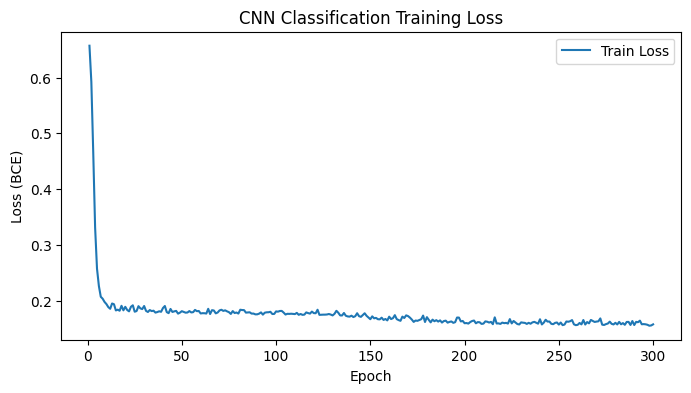

In [5]:
# 3. Set loss function and optimizer (BCEWithLogitsLoss for binary classification)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# List to store loss for each epoch
train_losses = []

# 4. Train the model
print("Starting CNN classification model training...")
for epoch_idx in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch_idx + 1) % 30 == 0:
        print(f"Epoch [{epoch_idx+1}/{epochs}], Loss: {avg_loss:.4f}")

print("CNN training complete!\n")

# Plot CNN training loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.title('CNN Classification Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.legend()
plt.show()

### 3. CNN Model Evaluation and Performance Visualization

Test Accuracy: 91.56%
Test Precision: 0.9295
Test Recall: 0.8629
Test F1 Score: 0.8950


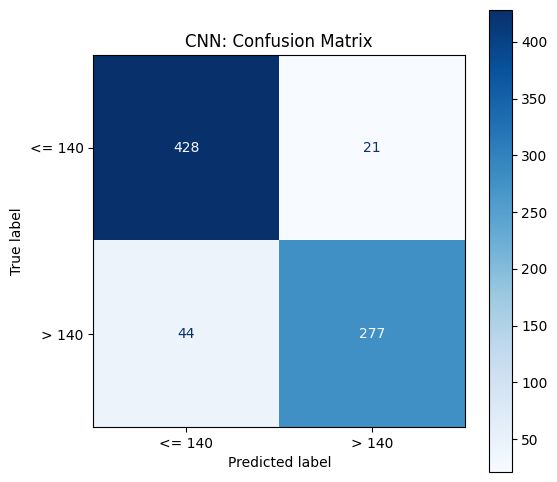

In [6]:
# 5. Model Evaluation
model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test_tensor)
    # Use sigmoid to convert logits to probabilities, and a threshold of 0.5 to determine class
    y_pred_probs = torch.sigmoid(y_pred_logits).squeeze().numpy()
    y_pred = (y_pred_probs > 0.5).astype(int)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy: {acc:.2%}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1 Score: {f1:.4f}")

# 6. Visualize prediction results (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<= 140', '> 140'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('CNN: Confusion Matrix')
plt.show()

### 4. Multi-Layer Perceptron (MLP) Model Definition and Training

Starting MLP classification model training...
Epoch [50/300], Loss: 0.1505
Epoch [100/300], Loss: 0.1452
Epoch [150/300], Loss: 0.1392
Epoch [200/300], Loss: 0.1389
Epoch [250/300], Loss: 0.1318
Epoch [300/300], Loss: 0.1235
MLP training complete!



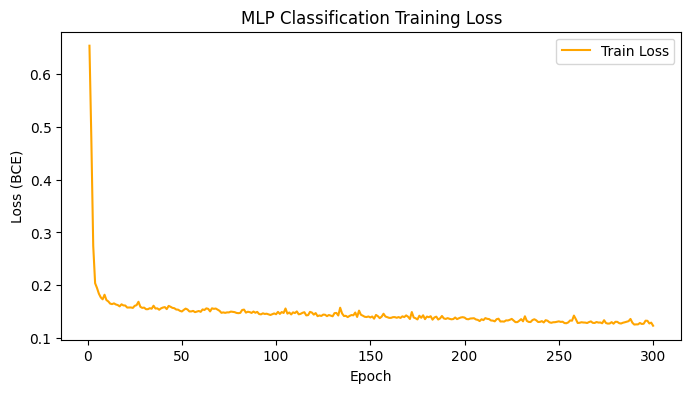

In [7]:
# 1. Define a simple MLP model
class SimpleMLP(nn.Module):
    def __init__(self, num_features):
        super(SimpleMLP, self).__init__()
        # Input feature count dynamically set to num_features
        self.fc1 = nn.Linear(num_features, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, 1)
        self.num_features = num_features

    def forward(self, x):
        # Flatten to (batch, num_features)
        x = x.view(-1, self.num_features)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

mlp_model = SimpleMLP(num_features)

# 2. Set loss function and optimizer
mlp_criterion = nn.BCEWithLogitsLoss()
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=lr)
mlp_epochs = epochs

# List to store loss for each epoch
mlp_train_losses = []

# 3. Train the MLP model
print("Starting MLP classification model training...")
for epoch_idx in range(mlp_epochs):
    mlp_model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        mlp_optimizer.zero_grad()
        outputs = mlp_model(batch_X)
        loss = mlp_criterion(outputs, batch_y)
        loss.backward()
        mlp_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    mlp_train_losses.append(avg_loss)

    if (epoch_idx + 1) % 50 == 0:
        print(f"Epoch [{epoch_idx+1}/{mlp_epochs}], Loss: {avg_loss:.4f}")

print("MLP training complete!\n")

# Plot MLP training loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, mlp_epochs + 1), mlp_train_losses, label='Train Loss', color='orange')
plt.title('MLP Classification Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.legend()
plt.show()


### 5. MLP Model Evaluation and Result Visualization

MLP Test Accuracy: 92.08%
MLP Test Precision: 0.9514
MLP Test Recall: 0.8536
MLP Test F1 Score: 0.8998


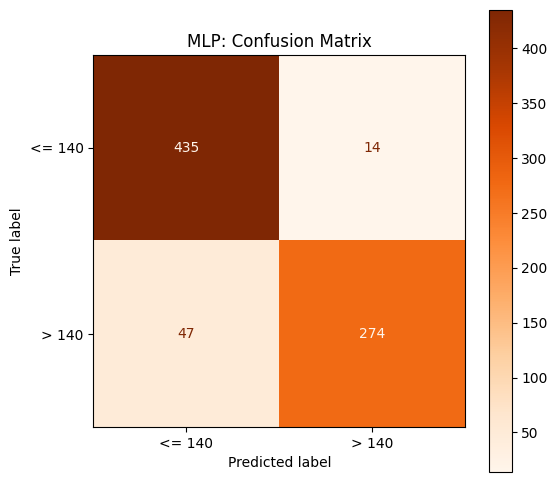

In [8]:
# 4. Model Evaluation
mlp_model.eval()
with torch.no_grad():
    # Use the same test set tensor
    mlp_y_pred_logits = mlp_model(X_test_tensor)
    mlp_y_pred_probs = torch.sigmoid(mlp_y_pred_logits).squeeze().numpy()
    mlp_y_pred = (mlp_y_pred_probs > 0.5).astype(int)

# Calculate metrics
mlp_acc = accuracy_score(y_test, mlp_y_pred)
mlp_prec = precision_score(y_test, mlp_y_pred)
mlp_rec = recall_score(y_test, mlp_y_pred)
mlp_f1 = f1_score(y_test, mlp_y_pred)

print(f"MLP Test Accuracy: {mlp_acc:.2%}")
print(f"MLP Test Precision: {mlp_prec:.4f}")
print(f"MLP Test Recall: {mlp_rec:.4f}")
print(f"MLP Test F1 Score: {mlp_f1:.4f}")

# 5. Visualize prediction results (Confusion Matrix)
mlp_cm = confusion_matrix(y_test, mlp_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=mlp_cm, display_labels=['<= 140', '> 140'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Oranges, ax=ax)
plt.title('MLP: Confusion Matrix')
plt.show()

### 6. Random Forest and Support Vector Machine (SVM) Model Analysis

Starting Random Forest model training...
Random Forest Test Accuracy: 92.08%
Random Forest Test Precision: 0.9221
Random Forest Test Recall: 0.8847
Random Forest Test F1 Score: 0.9030

Starting SVM model training...
SVM Test Accuracy: 91.69%
SVM Test Precision: 0.9269
SVM Test Recall: 0.8692
SVM Test F1 Score: 0.8971



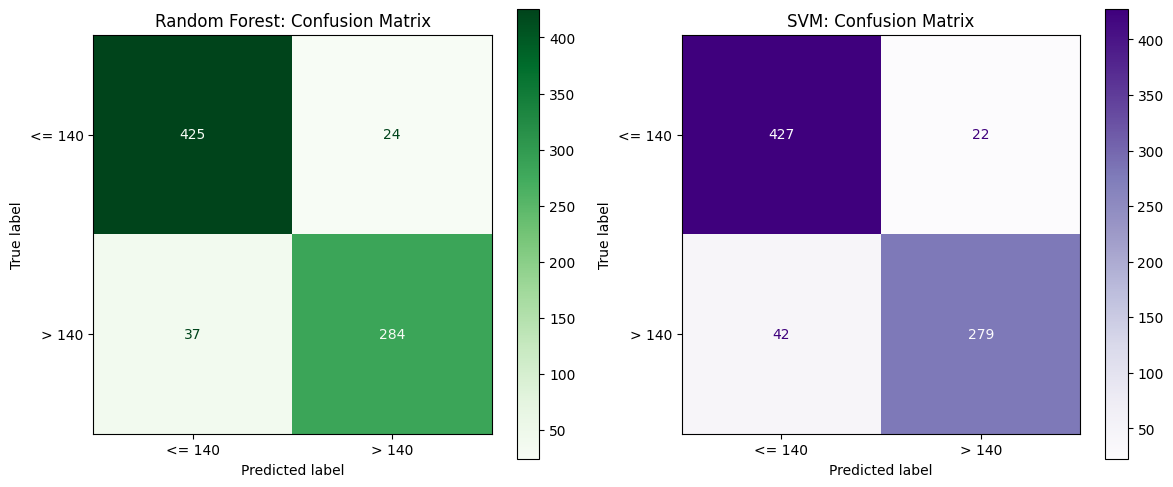

In [9]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 1. Train and evaluate Random Forest model
print("Starting Random Forest model training...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_y_pred = rf_model.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, rf_y_pred)
rf_prec = precision_score(y_test, rf_y_pred)
rf_rec = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)

print(f"Random Forest Test Accuracy: {rf_acc:.2%}")
print(f"Random Forest Test Precision: {rf_prec:.4f}")
print(f"Random Forest Test Recall: {rf_rec:.4f}")
print(f"Random Forest Test F1 Score: {rf_f1:.4f}\n")

# 2. Train and evaluate SVM model
print("Starting SVM model training...")
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_y_pred = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_y_pred)
svm_prec = precision_score(y_test, svm_y_pred)
svm_rec = recall_score(y_test, svm_y_pred)
svm_f1 = f1_score(y_test, svm_y_pred)

print(f"SVM Test Accuracy: {svm_acc:.2%}")
print(f"SVM Test Precision: {svm_prec:.4f}")
print(f"SVM Test Recall: {svm_rec:.4f}")
print(f"SVM Test F1 Score: {svm_f1:.4f}\n")

# 3. Visualize prediction results (Confusion Matrix)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_y_pred)
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['<= 140', '> 140'])
rf_disp.plot(cmap=plt.cm.Greens, ax=axes[0])
axes[0].set_title('Random Forest: Confusion Matrix')

# SVM Confusion Matrix
svm_cm = confusion_matrix(y_test, svm_y_pred)
svm_disp = ConfusionMatrixDisplay(confusion_matrix=svm_cm, display_labels=['<= 140', '> 140'])
svm_disp.plot(cmap=plt.cm.Purples, ax=axes[1])
axes[1].set_title('SVM: Confusion Matrix')

plt.tight_layout()
plt.show()